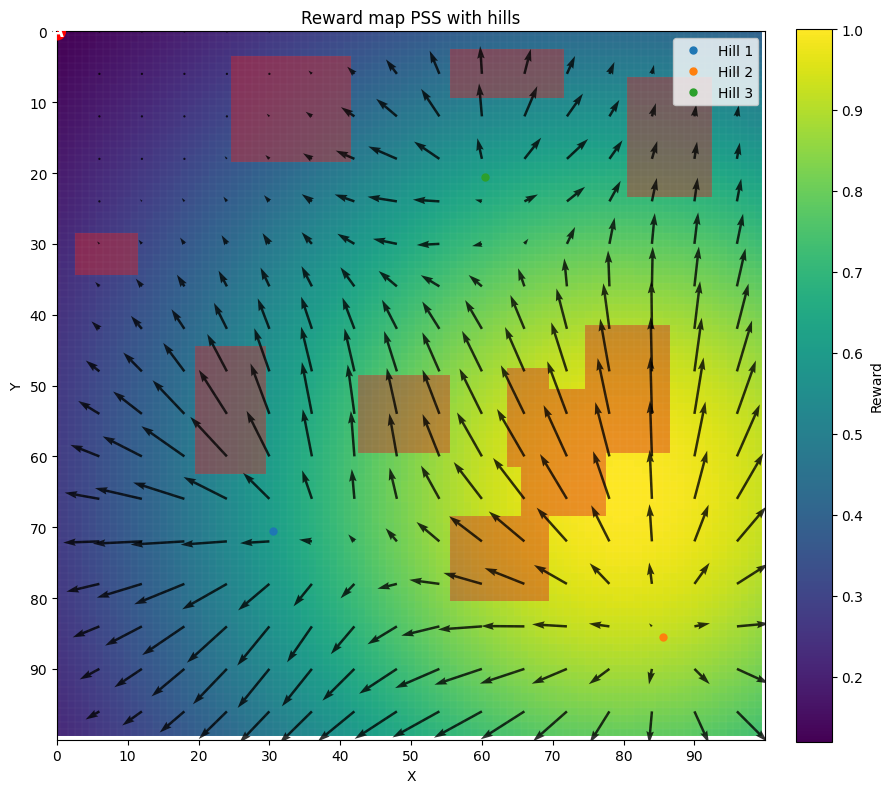

In [76]:
from pathlib import Path
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
import sys
import numpy as np
from scipy.stats import multivariate_normal
from tqdm import tqdm
import torch

start_state = (0, 0)

def plot_agent(location, ax=None, radius=1.2):
    x, y = location
    agent = Circle((x, y), radius=radius, color='red', zorder=3)
    ax.add_patch(agent)

    # Draw white 'A' in the center
    ax.text(
        x, y, 'A',
        color='white',
        fontsize=12,
        fontweight='bold',
        ha='center',
        va='center',
        zorder=4
    )


# Ensure project root (parent of notebooks/) is on PYTHONPATH
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import directly from module (not from src/__init__.py)
from src.environment_2 import ProbabilisticSimpleSystem

env = ProbabilisticSimpleSystem(seed=64, reward_scale=10.0, reward_gaussian_sigma=50.0)
env.clear_hills()
env.add_hill(top=(30, 70), sigma=15.0, strength=35, normalized=False)
env.add_hill(top=(85, 85), sigma=30.0, strength=100, normalized=False)
env.add_hill(top=(60, 20), sigma = 10, strength=15.0, normalized=False)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
env.plot_combined(ax=ax)
env.plot_hills(ax=ax)
ax.set_title("Reward map PSS with hills")
plot_agent(start_state, ax=ax)
plt.show()

max_x, max_y = env.grid_shape

actions = {
    'up': (0, -1),
    'right': (1, 0),
    'down': (0, 1),
    'left': (-1, 0),
}

states_visited = {start_state: 1}

In [ ]:
def get_action(state, epsilon, q_values):
    if np.random.rand() < epsilon:
        action_index = np.random.choice(len(actions))
        action = list(actions.values())[action_index]  
    else:
        x, y = state
        action_index = np.argmax(q_values[x, y, :])
        action = list(actions.values())[action_index]
    return action, action_index

(x_top, y_top) = env.reward_gaussian_mean

def square_keep_sign(n):
    if n >= 0:
        return n ** 2
    else:
        return -(n ** 2)

def distance_to_goal(state):
    x, y = state
    return np.sqrt((x - y_top) ** 2 + (y - x_top) ** 2)

In [78]:
# N samples x M tasks, (0,4) as we have not sampled yet
train_x = torch.empty((0, 4), dtype=torch.float64)
train_y = torch.empty((0, 2), dtype=torch.float64)

Q = np.zeros((max_x, max_y, len(actions)))  # 100 x 100 x 4
EPISODES = 5000
MAX_STEPS = 200
ALPHA = 0.3
GAMMA = 0.9
EPSILON = 1
EPSILON_DECAY = 0.9995
MIN_EPSILON = 0.1

# takes ~50 mins
# EPISODES = 2000
# MAX_STEPS = 1000
# ALPHA = 0.9
# GAMMA = 0.99
# EPSILON = 1
# EPSILON_DECAY = 0.995
# MIN_EPSILON = 0.1

for episode in tqdm(range(EPISODES), desc="Training Episodes"):
    s = start_state

    for step in range(MAX_STEPS):
        x, y = s

        a, a_index = get_action(s, EPSILON, Q)
        s_prime = env.transition(s, a)

        if distance_to_goal(s_prime) < 5:
            r = 100
        else:
            # r = env.get_reward(s_prime) - 10
            # r = distance_to_goal(s_prime) * -2 + r
            r = square_keep_sign(distance_to_goal(s) - distance_to_goal(s_prime)) - 10

        states_visited[s_prime] = states_visited.get(s_prime, 0) + 1

        x_prime, y_prime = s_prime


        best_next_q = np.max(Q[x_prime, y_prime, :])

        # Bellman equation
        # $Q(s, a) = (1 - \alpha) Q(s, a) + \alpha (r + \gamma \max_{a'} Q(s', a'))$
        Q[x, y, a_index] = (
            (1 - ALPHA) * Q[x, y, a_index]
            + ALPHA * (r + GAMMA * best_next_q)
        )

        # if step == MAX_STEPS - 1 and episode % 100 == 0:
        #     print(f"Episode {episode+1}/{EPISODES} ended at max steps. Last state: {s_prime}, reward: {r:.2f}")

        # get training data for the GP
        train_x = torch.cat((train_x, torch.tensor([[x, y, a[0], a[1]]], dtype=torch.float64)), dim=0)
        train_y = torch.cat((train_y, torch.tensor([[x_prime, y_prime]], dtype=torch.float64)), dim=0)

        s = s_prime

        if distance_to_goal(s) < 5:
            break



    EPSILON = max(MIN_EPSILON, EPSILON * EPSILON_DECAY)

Training Episodes: 100%|██████████| 5000/5000 [07:12<00:00, 11.57it/s]


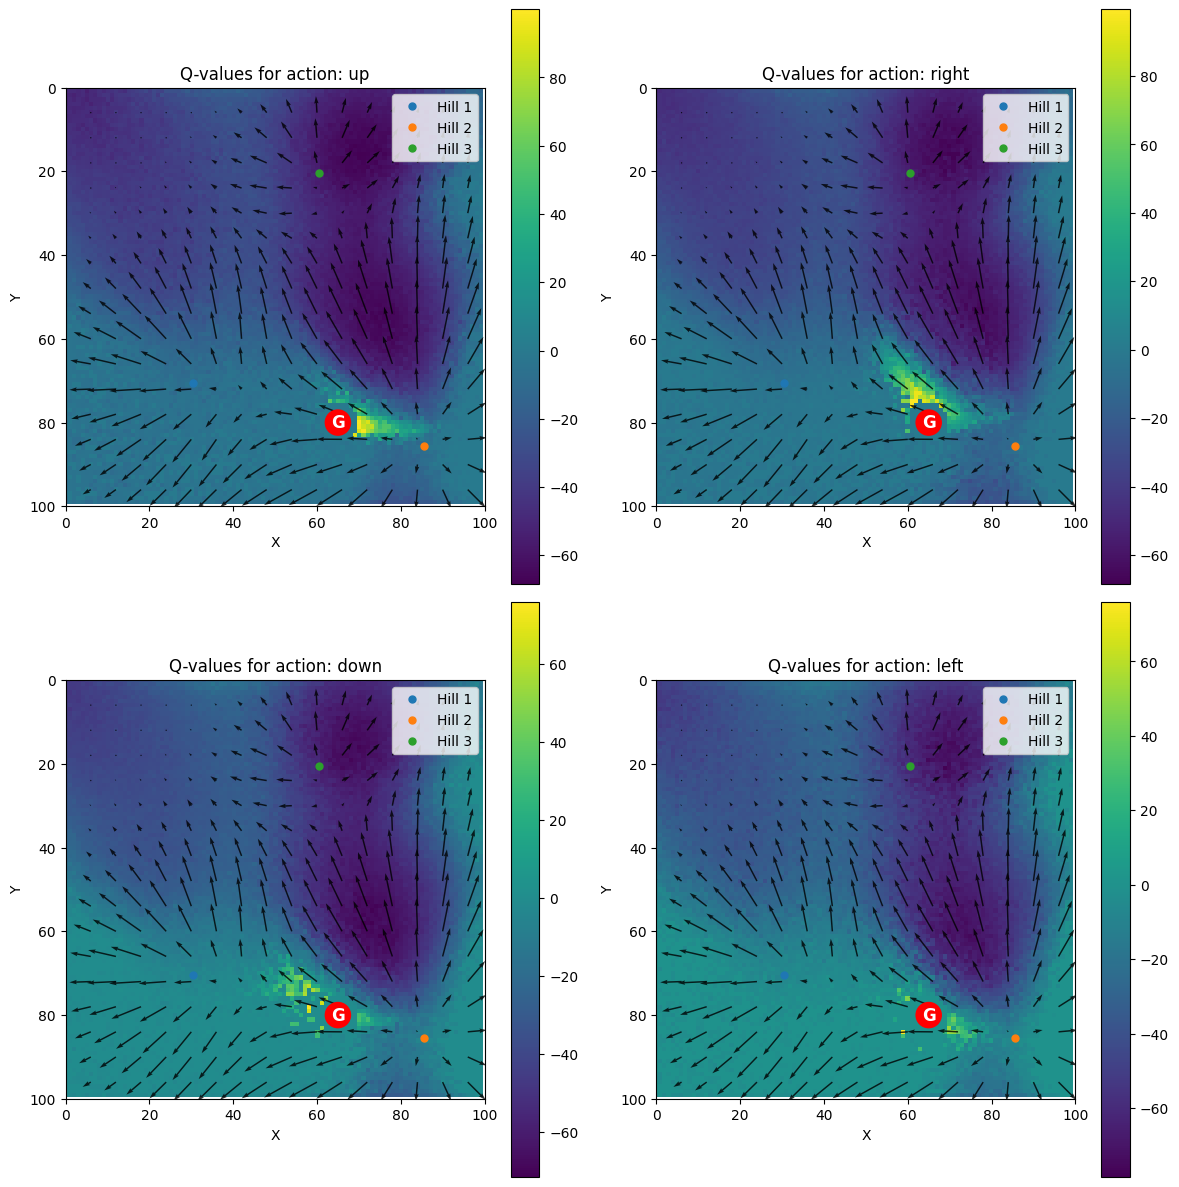

In [ ]:
def visualize_q_values(Q, env=env):
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    action_names = list(actions.keys())
    
    for i, ax in enumerate(axes.flatten()):
        im = ax.imshow(Q[:, :, i], cmap='viridis')
        ax.set_title(f"Q-values for action: {action_names[i]}")
        fig.colorbar(im, ax=ax)
        env.plot_hills(ax=ax) 

        goal = Circle((x_top, y_top), radius=3, color='red', zorder=3)
        ax.add_patch(goal)

        # Draw white 'G' in the center
        ax.text(
            x_top, y_top, 'G',
            color='white',
            fontsize=12,
            fontweight='bold',
            ha='center',
            va='center',
            zorder=4
        ) 
    
    plt.tight_layout()
    plt.show()

visualize_q_values(Q)

/var/folders/rv/b01cr15x4v1d0l_0f9t176nr0000gn/T/ipykernel_14510/3069102751.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', max(num_runs, 1))


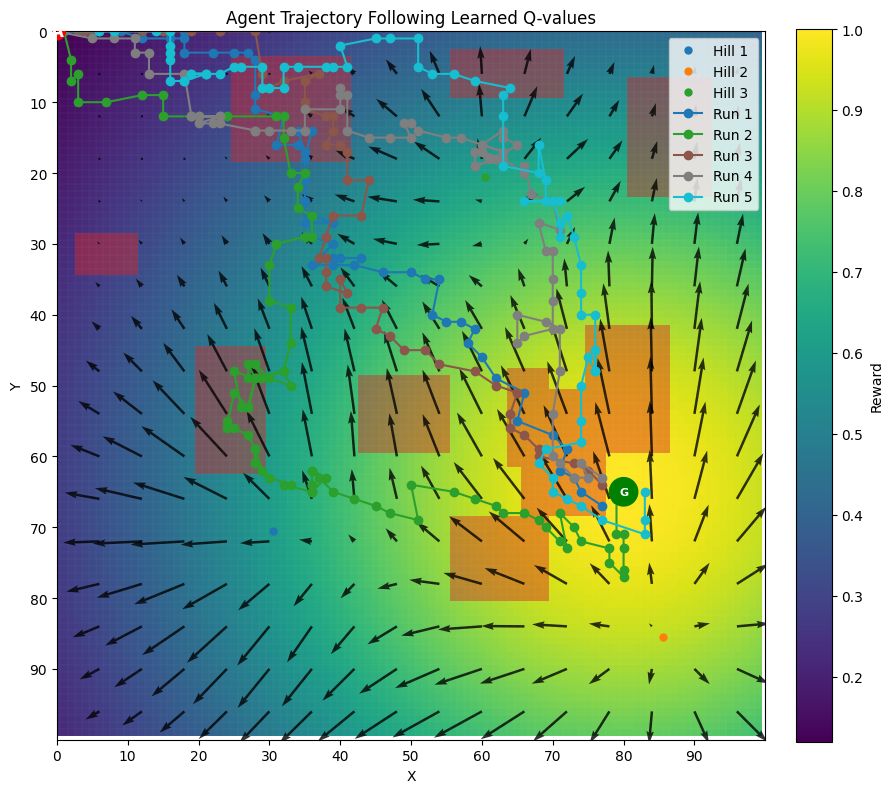

In [177]:
def plot_run(Q, env, start_state, max_steps=1000, num_runs=1):
    fig, ax = plt.subplots(figsize=(10, 10))
    env.plot_combined(ax=ax)
    env.plot_hills(ax=ax)
    plot_agent(start_state, ax=ax)

    goal = Circle((y_top, x_top), radius=2, color='green', zorder=3)
    ax.add_patch(goal)

    # Draw white 'G' in the center
    ax.text(
        y_top, x_top, 'G',
        color='white',
        fontsize=8,
        fontweight='bold',
        ha='center',
        va='center',
        zorder=4
    ) 

    colors = plt.cm.get_cmap('tab10', max(num_runs, 1))
    for run_idx in range(num_runs):
        s = start_state
        trajectory = [s]

        for _ in range(max_steps):
            x, y = s
            a_index = np.argmax(Q[x, y, :])
            a = list(actions.values())[a_index]
            s = env.transition(s, a)
            trajectory.append(s)

            if distance_to_goal(s) < 5:
                break

        traj_x, traj_y = zip(*trajectory)
        ax.plot(
            traj_x, traj_y,
            marker='o',
            color=colors(run_idx),
            label=f'Run {run_idx + 1}' if num_runs > 1 else 'Agent Trajectory'
        )
    ax.legend()
    plt.title("Agent Trajectory Following Learned Q-values")
    plt.show()

plot_run(Q, env, start_state, num_runs=5)

In [81]:
print(f"Unique states visited: {len(states_visited)}")

Unique states visited: 9657


/var/folders/rv/b01cr15x4v1d0l_0f9t176nr0000gn/T/ipykernel_14510/457851560.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  action_cmap = plt.cm.get_cmap('tab10', 4)


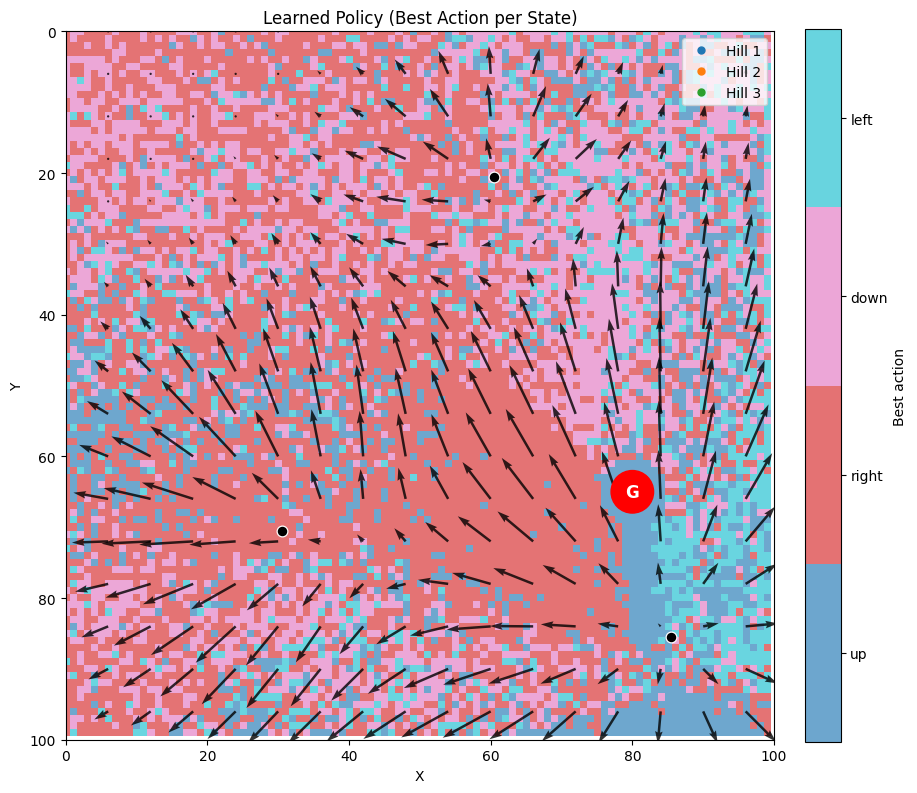

In [ ]:
def plot_policy(Q, env):
    max_x, max_y = env.grid_shape
    policy_grid = np.argmax(Q, axis=2)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Color each state by its best action (no policy arrows).
    # Use top-origin to match the rest of the environment visualizations (y=0 at top).
    action_cmap = plt.cm.get_cmap('tab10', 4)
    im = ax.imshow(
        policy_grid.T,
        cmap=action_cmap,
        origin='upper',
        interpolation='nearest',
        vmin=-0.5,
        vmax=3.5,
        alpha=0.65
    )
    
    # Keep hill vectors and hill-top markers on top.
    env.plot_hills(ax=ax, color='black')
    for top, *_ in env.hill_tops:
        tx, ty = top
        ax.scatter(tx + 0.5, ty + 0.5, s=60, c='black', edgecolors='white', linewidths=0.9, zorder=6)

    goal = Circle((y_top, x_top), radius=3, color='red', zorder=3)
    ax.add_patch(goal)

    # Draw white 'G' in the center
    ax.text(
        y_top, x_top, 'G',
        color='white',
        fontsize=12,
        fontweight='bold',
        ha='center',
        va='center',
        zorder=4
    ) 
    
    
    cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], fraction=0.046, pad=0.04)
    cbar.ax.set_yticklabels(['up', 'right', 'down', 'left'])
    cbar.set_label('Best action')
    
    ax.set_title('Learned Policy (Best Action per State)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    plt.show()


plot_policy(Q, env)